# Daily Challenge: Classifying Handwritten Digits with CNNs


## 1. Load the MNIST dataset:

- Use keras.datasets.mnist.load_data() to load the training and testing data.
- Print the shapes of the loaded data to understand the dataset structure.

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print('MNIST dataset loaded !')
print(f'Training X_train shape: {X_train.shape}')
print(f'Training y_train shape: {y_train.shape}')
print(f'Test X_test shape: {X_test.shape}')
print(f'Test y_test shape: {y_test.shape}')
print(f"\nLabels: {np.unique(y_train)} (digits 0-9)")

print(f"Pixel value range: {X_train.min()} to {X_train.max()}")


MNIST dataset loaded !
Training X_train shape: (60000, 28, 28)
Training y_train shape: (60000,)
Test X_test shape: (10000, 28, 28)
Test y_test shape: (10000,)

Labels: [0 1 2 3 4 5 6 7 8 9] (digits 0-9)
Pixel value range: 0 to 255


## 2. Preprocess the data for a Fully Connected Neural Network:

- Flatten the images from 28x28 to 784 pixels.
- Normalize the pixel values by dividing by 255.
- One-hot encode the target labels using keras.utils.np_utils.to_categorical().

In [13]:
X_train_normal = X_train / 255.
X_test_normal = X_test / 255.
print(f"Pixel value range: {X_train_normal.min()} to {X_train_normal.max()}")


Pixel value range: 0.0 to 1.0


In [14]:
from tensorflow.keras.utils import to_categorical

y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh = to_categorical(y_test, num_classes=10)
print(f'After ont-hot encoding, Output shape: {y_train_oh.shape}')


After ont-hot encoding, Output shape: (60000, 10)


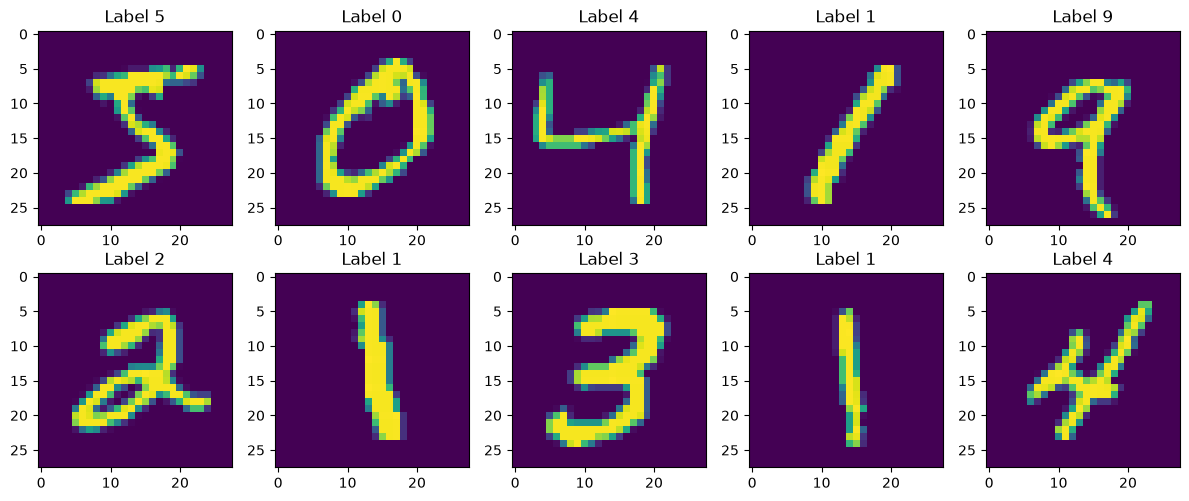

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(f'Label {y_train[i]}')

plt.tight_layout()
plt.show()

## 3. Build and train a Fully Connected Neural Network:

- Create a Sequential model.
- Add Dense layers with appropriate activation functions (e.g., ReLU and softmax).
- Compile the model with an optimizer (e.g., Adam), loss function (e.g., categorical cross-entropy), and metrics (e.g., accuracy).
- Train the model using model.fit() and evaluate its performance.

In [16]:
from tensorflow.keras import models, layers

model_dense = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_dense.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_dense.summary()

dense_nn = model_dense.fit(X_train_normal, y_train_oh, epochs=8, batch_size=32, validation_split=0.1)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9244 - loss: 0.2553 - val_accuracy: 0.9677 - val_loss: 0.1141
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9681 - loss: 0.1072 - val_accuracy: 0.9735 - val_loss: 0.0952
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9764 - loss: 0.0734 - val_accuracy: 0.9690 - val_loss: 0.1075
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9824 - loss: 0.0557 - val_accuracy: 0.9763 - val_loss: 0.0832
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9848 - loss: 0.0457 - val_accuracy: 0.9758 - val_loss: 0.0848
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9891 - loss: 0.0342 - val_accuracy: 0.9777 - val_loss: 0.0827
Epoch 7/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9905 - loss: 0.0292 - val_accuracy: 0.9738 - val_loss: 0.1121
Epoch 8/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9917 - loss: 0.0250 - val_accu

In [17]:
loss_dense, acc_dense = model_dense.evaluate(X_test_normal, y_test_oh)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9757 - loss: 0.0890


## 4. Preprocess the data for a Convolutional Neural Network:

- Reshape the input data to the shape expected by a Conv2D layer (e.g., (60000, 28, 28, 1)).
- Normalize the pixel values by dividing by 255.
- One-hot encode the target labels using keras.utils.np_utils.to_categorical().

## 5. Build and train a Convolutional Neural Network:

- Create a Sequential model.
- Add Conv2D and MaxPool2D layers.
- Add a Flatten layer.
- Add Dense layers with appropriate activation functions.
- Compile and train the model, similar to the Fully Connected Neural Network.

In [18]:
model_cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPool2D((2, 2)),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPool2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_cnn = model_cnn.fit(X_train, y_train_oh, epochs=8, batch_size=32, validation_split=0.1)

loss_cnn, accuracy_cnn = model_cnn.evaluate(X_test, y_test_oh)

Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.9582 - loss: 0.1349 - val_accuracy: 0.9885 - val_loss: 0.0405
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.9861 - loss: 0.0446 - val_accuracy: 0.9882 - val_loss: 0.0401
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.9904 - loss: 0.0289 - val_accuracy: 0.9855 - val_loss: 0.0493
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.9929 - loss: 0.0212 - val_accuracy: 0.9878 - val_loss: 0.0419
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.9949 - loss: 0.0148 - val_accuracy: 0.9908 - val_loss: 0.0331
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 22ms/step - accuracy: 0.9956 - loss: 0.0125 - val_accuracy: 0.9918 - val_loss: 0.0321
Epoch 7/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.9968 - loss: 0.0093 - val_accuracy: 0.9915 - val_loss: 0.0321
Epoch 8/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9971 - loss: 0

In [20]:
# COMPARISON: Dense vs CNN

print("\n" + "=" * 60)
print("           MODEL COMPARISON")
print("=" * 60)
print(f"\n{'Metric':<25} {'Dense':>15} {'CNN':>15}")
print("-" * 60)
print(f"{'Test Accuracy':<25} {acc_dense:>14.2%} {accuracy_cnn:>14.2%}")
print(f"{'Correct (out of 10,000)':<25} {int(acc_dense*10000):>15,} {int(accuracy_cnn*10000):>15,}")
print(f"{'Errors':<25} {int((1-acc_dense)*10000):>15,} {int((1-accuracy_cnn)*10000):>15,}")
print(f"{'Parameters':<25} {model_dense.count_params():>15,} {model_cnn.count_params():>15,}")
print("=" * 60)

improvement = (accuracy_cnn - acc_dense) * 100
error_reduction = (1 - accuracy_cnn) / (1 - acc_dense)
print(f"\nCNN improved accuracy by {improvement:.2f} percentage points")
print(f"CNN reduced errors by {(1-error_reduction)*100:.1f}%!")


           MODEL COMPARISON

Metric                              Dense             CNN
------------------------------------------------------------
Test Accuracy                     97.57%         98.86%
Correct (out of 10,000)             9,757           9,886
Errors                                242             113
Parameters                        109,386         421,642

CNN improved accuracy by 1.29 percentage points
CNN reduced errors by 53.1%!
